In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
from scipy import stats

In [2]:
df = pd.read_csv('..\\data\\raw\\df_train.csv')

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,26,62000,RENT,1.0,DEBTCONSOLIDATION,B,10000,11.26,0.16,N,2,0
1,23,39000,MORTGAGE,3.0,EDUCATION,C,5000,12.98,0.13,N,4,0
2,24,35000,RENT,1.0,DEBTCONSOLIDATION,A,12000,6.54,0.34,N,2,1
3,24,86000,RENT,1.0,HOMEIMPROVEMENT,B,12000,10.65,0.14,N,3,0
4,42,38400,RENT,4.0,MEDICAL,B,13000,NaN,0.34,N,11,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22806 entries, 0 to 22805
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  22806 non-null  int64  
 1   person_income               22806 non-null  int64  
 2   person_home_ownership       22806 non-null  str    
 3   person_emp_length           22167 non-null  float64
 4   loan_intent                 22806 non-null  str    
 5   loan_grade                  22806 non-null  str    
 6   loan_amnt                   22806 non-null  int64  
 7   loan_int_rate               20606 non-null  float64
 8   loan_percent_income         22806 non-null  float64
 9   cb_person_default_on_file   22806 non-null  str    
 10  cb_person_cred_hist_length  22806 non-null  int64  
 11  loan_status                 22806 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 2.5 MB


In [5]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,22806.000000,2.280600e+04,22167.000000,22806.000000,20606.000000,22806.000000,22806.000000,22806.000000
mean,27.722880,6.620697e+04,4.796905,9598.740463,11.010418,0.170173,5.797992,0.218144
std,6.336638,6.387456e+04,4.120061,6313.133319,3.228057,0.106759,4.056109,0.412995
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,23.000000,3.852475e+04,2.000000,5000.000000,7.900000,0.090000,3.000000,0.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.150000,4.000000,0.000000
75%,30.000000,7.963500e+04,7.000000,12250.000000,13.470000,0.230000,8.000000,0.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,22.480000,0.830000,30.000000,1.000000


In [6]:
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 22806
Quantidade de colunas: 12


In [7]:
numerical_cols = df.select_dtypes(include='number')
numerical_cols.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'loan_status'],
      dtype='str')

In [8]:
categorical_cols = df.select_dtypes(include=['object', 'string', 'boolean'])
categorical_cols.columns

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='str')

# Target Feature Distribution

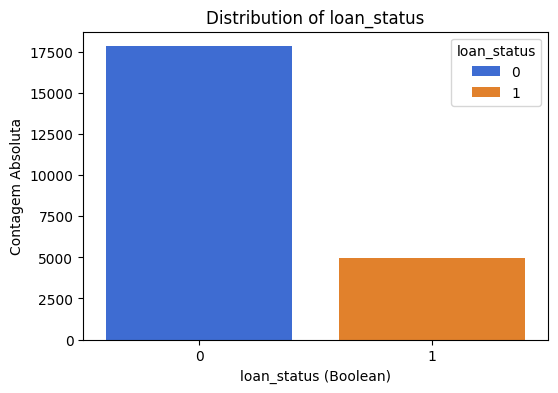

In [9]:
plt.figure(figsize=(6, 4))

# CORREÇÃO: Usamos o countplot. Ele precisa apenas do eixo X e calcula a contagem sozinho.
sns.countplot(x='loan_status', data=df, palette=['#2563eb', '#ff7f0e'], hue= 'loan_status')

# Configurações do gráfico
plt.title("Distribution of loan_status", fontsize=12)
plt.xlabel("loan_status (Boolean)")
plt.ylabel("Contagem Absoluta")

# Mostra o gráfico
plt.show()

A análise da variável *target* revelou um desbalanceamento acentuado, com predominância de casos de adimplência (status 0).

Este comportamento é típico em modelos de risco de crédito. Para evitar um modelo enviesado que priorize apenas a classe majoritária, aplicaremos técnicas de reamostragem ou ajustes de pesos (class weights) no treinamento.

# Correlation for numerical columns

## Correlation between features

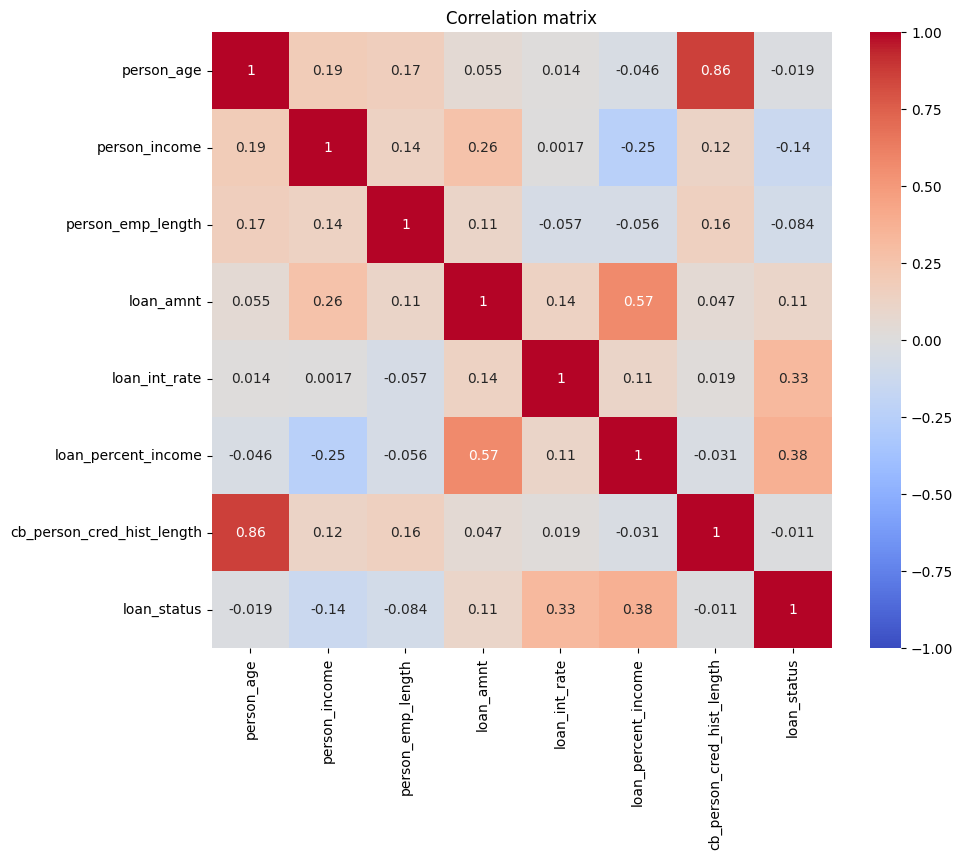

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_cols.corr(method='pearson'),annot=True, cmap="coolwarm", center=0,vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()

O mapa de calor revelou uma correlação linear positiva extremamente forte de **0,86** entre a idade do cliente (**`person_age`**) e o tempo do seu histórico de crédito (**`cb_person_cred_hist_length`**). 

Esta altíssima correlação reflete uma dependência temporal natural de negócio: o tempo de histórico de crédito é biologicamente limitado pela idade do indivíduo. Manter ambas as variáveis em modelos lineares (como a Regressão Logística) gera multicolinearidade, o que infla a variância dos coeficientes e gera instabilidade na interpretação do impacto isolado de cada atributo.

## Correlation between target x numerical features

### Pearson correlation

In [11]:
corr_pearson= numerical_cols.corr(method='pearson')['loan_status']
#calcula as correlações entre as variáveis numéricas do DataFrame.
corr_pearson.sort_values(ascending=False)

loan_status                   1.000000
loan_percent_income           0.378112
loan_int_rate                 0.327949
loan_amnt                     0.106442
cb_person_cred_hist_length   -0.011021
person_age                   -0.018554
person_emp_length            -0.084284
person_income                -0.139836
Name: loan_status, dtype: float64

In [12]:
maiores_correlacoes_pearson = corr_pearson[abs(corr_pearson) > 0.5].sort_values(ascending=False)
maiores_correlacoes_pearson

loan_status    1.0
Name: loan_status, dtype: float64

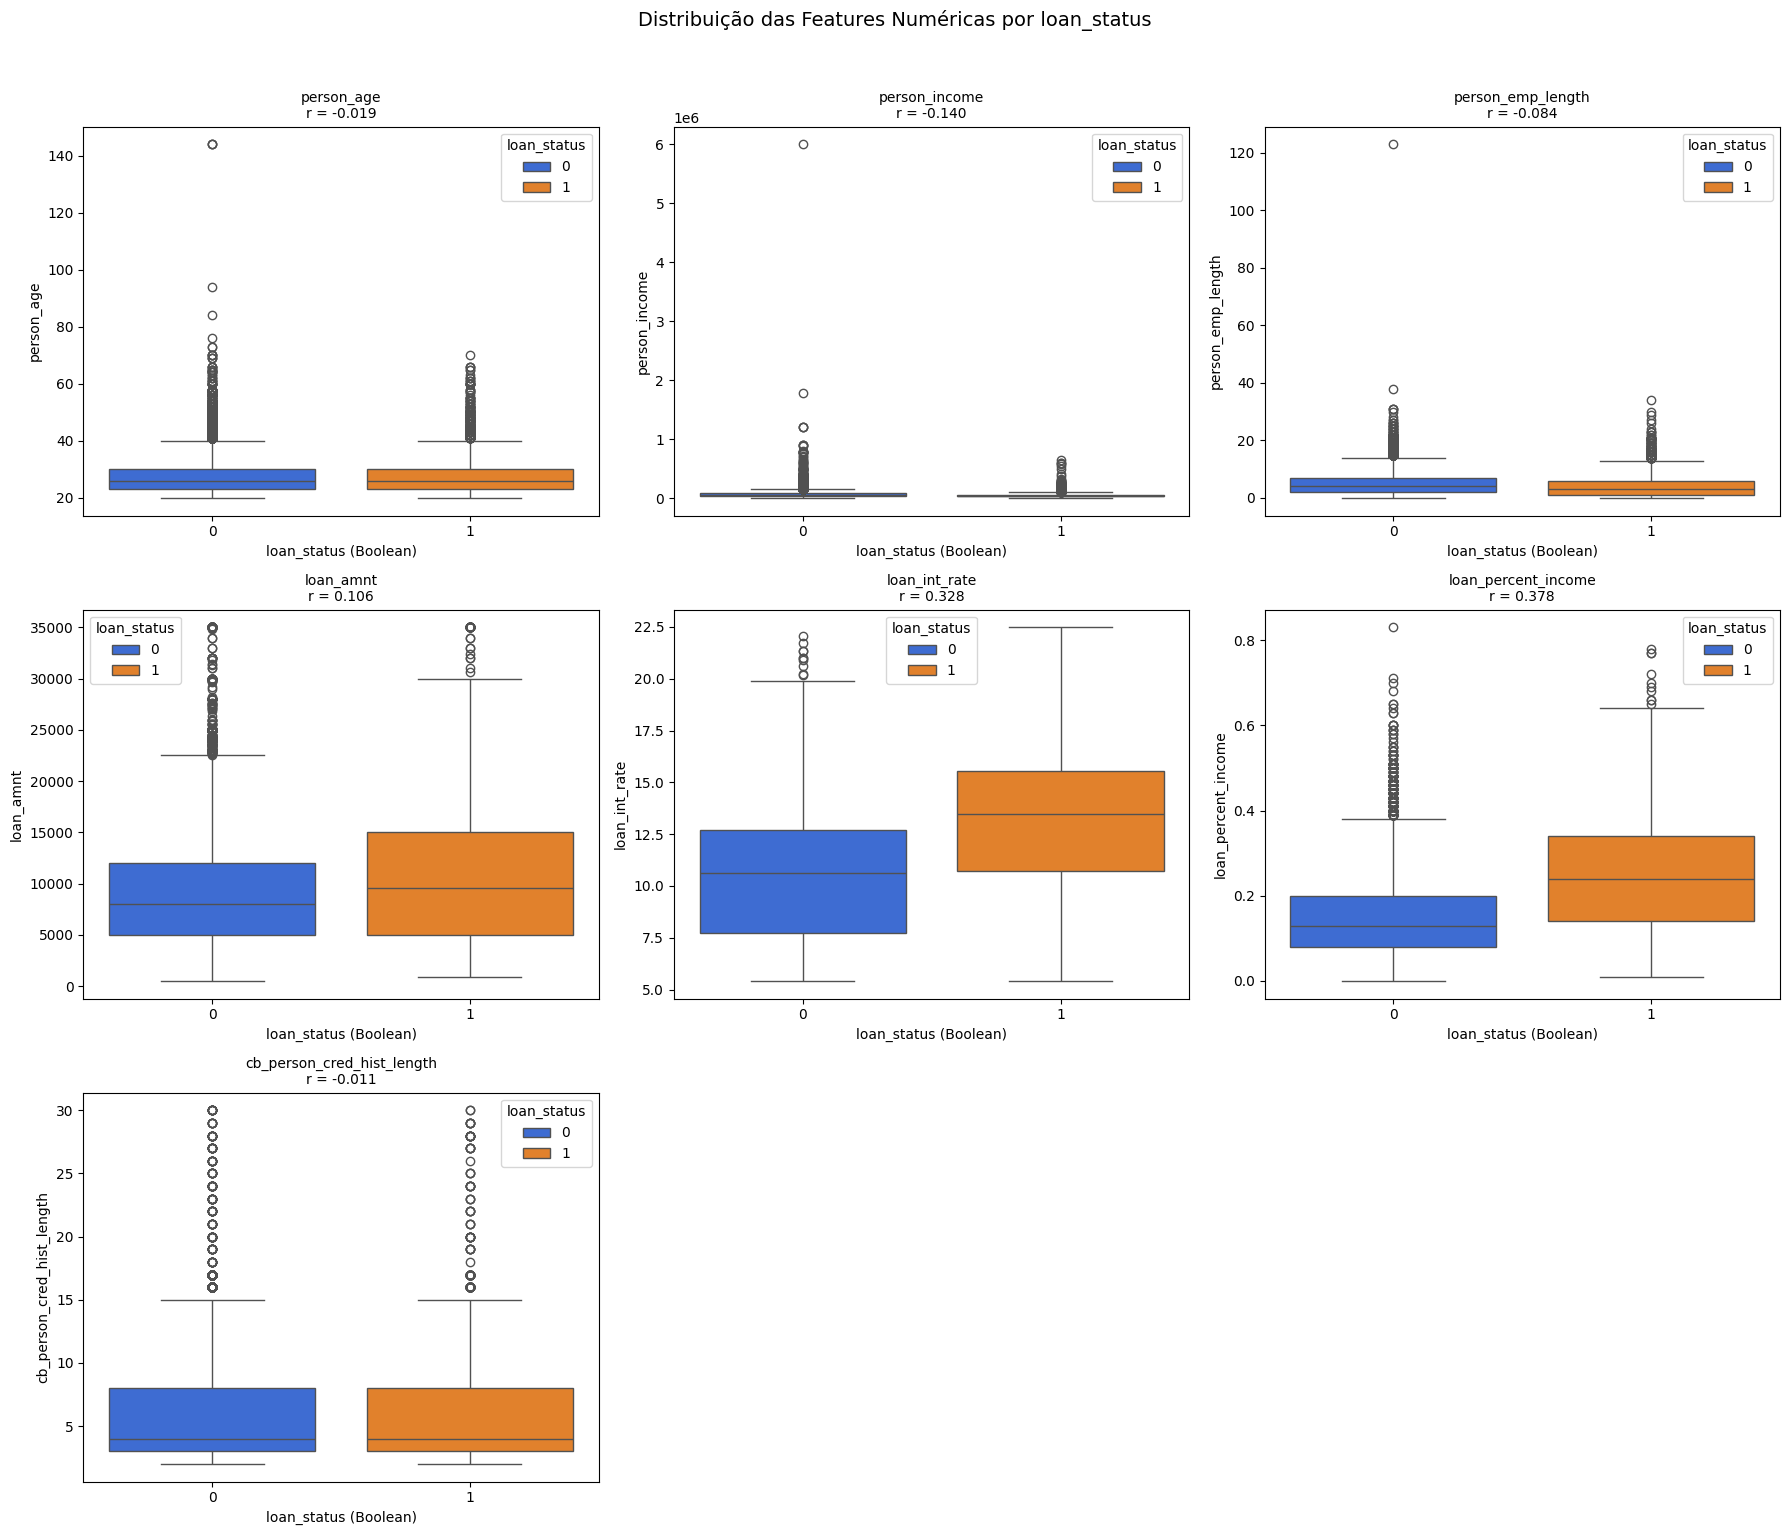

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# Note que usamos 'numerical_cols' como o DataFrame completo aqui
for i, col in enumerate(corr_pearson.drop('loan_status').index):
    r = corr_pearson[col]
    
    # Plota o boxplot separando a variável numérica pelo loan_status
    sns.boxplot(
        data=numerical_cols, 
        x='loan_status', 
        y=col, 
        ax=axes[i], 
        palette=['#2563eb', '#ff7f0e'],
        hue='loan_status',
    )
    
    axes[i].set_xlabel('loan_status (Boolean)')
    axes[i].set_ylabel(col)
    # Mantém o coeficiente r de Pearson no título para você comparar
    axes[i].set_title(f'{col}\nr = {r:.3f}', fontsize=10)

# Esconder subplots que sobrarem caso você não tenha exatamente 8 variáveis
for j in range(len(corr_pearson.drop('loan_status').index), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das Features Numéricas por loan_status', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Spearman correlation

In [14]:
corr_sperman = df.corr(method='spearman', numeric_only=True)['loan_status'].abs().sort_values(ascending=False)
corr_sperman

loan_status                   1.000000
loan_percent_income           0.315230
loan_int_rate                 0.313109
person_income                 0.272437
person_emp_length             0.097300
loan_amnt                     0.083476
person_age                    0.031942
cb_person_cred_hist_length    0.022121
Name: loan_status, dtype: float64

## Pearson x Spearman

In [15]:
comparacao = pd.DataFrame({
    'Pearson': corr_pearson,
    'Spearman': corr_sperman
}).dropna()

comparacao['Diferença'] = (comparacao['Spearman'].abs() - comparacao['Pearson'].abs()).round(4)
comparacao = comparacao.sort_values('Spearman', key=abs, ascending=False)

print(comparacao.head(15))

                             Pearson  Spearman  Diferença
loan_status                 1.000000  1.000000     0.0000
loan_percent_income         0.378112  0.315230    -0.0629
loan_int_rate               0.327949  0.313109    -0.0148
person_income              -0.139836  0.272437     0.1326
person_emp_length          -0.084284  0.097300     0.0130
loan_amnt                   0.106442  0.083476    -0.0230
person_age                 -0.018554  0.031942     0.0134
cb_person_cred_hist_length -0.011021  0.022121     0.0111


### Análise de Correlação: loan_status

Este resumo descreve a relação entre as variáveis do dataset e a variável alvo `loan_status`.

- **Pearson:** Avalia relações **lineares**.
- **Spearman:** Avalia relações **monotônicas** (mais robusto para não-linearidades e outliers).
- **Diferença:** Indica a discrepância entre os dois métodos, sugerindo a presença de comportamentos não lineares nos dados.


A análise de correlação destacou os principais impulsionadores de risco:

* **`loan_percent_income` (0,37):** Esta é a variável de maior impacto. O alto comprometimento da renda mensal com a parcela do empréstimo é o fator estatístico que mais se correlaciona com a inadimplência.

* **`loan_int_rate` (0,33):** Existe uma tendência estatística observada nos dados de que registros com valores mais altos na variável `loan_int_rate` (taxa de juros) estão associados a registros com valor 1 na variável `loan_status` (inadimplência), enquanto registros com taxas de juros menores estão mais associados ao valor 0 (adimplência).

* **`person_income` (-0,14):** Apresenta correlação negativa, reforçando que maiores patamares de renda atuam como fator de proteção financeira.

* **Fatores Demográficos:** As variáveis de idade e tempo de histórico de crédito apresentaram correlação quase nula, indicando que, sozinhas, não possuem poder discriminatório suficiente para prever inadimplência.

## Variance Inflation Factor (VIF) for numerical features

In [16]:
# seleciona as variáveis numéricas (sem loan_status)
vif_cols = numerical_cols.drop(columns=['loan_status']).dropna()

# calcula VIF para cada variável
vif_data = pd.DataFrame({
    'variavel': vif_cols.columns,
    'VIF': [variance_inflation_factor(vif_cols.values, i) for i in range(vif_cols.shape[1])]
})

# ordena do maior para o menor
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

# classifica o nível de multicolinearidade
def classifica_vif(vif):
    if vif >= 10:
        return 'grave'
    elif vif >= 5:
        return 'moderada'
    else:
        return 'baixa'

vif_data['multicolinearidade'] = vif_data['VIF'].apply(classifica_vif)

print(vif_data.to_string(index=False))

                  variavel       VIF multicolinearidade
                person_age 27.359019              grave
             loan_int_rate 10.569887              grave
cb_person_cred_hist_length  7.260187           moderada
       loan_percent_income  6.906217           moderada
                 loan_amnt  6.837195           moderada
             person_income  3.016710              baixa
         person_emp_length  2.476185              baixa


A análise do Fator de Inflação da Variância (VIF) revelou pontos de atenção significativos quanto à redundância de informações entre as variáveis preditoras:

- **Casos Críticos (VIF > 10):**
    - `person_age` (27.36) e `loan_int_rate` (10.57). Estes valores indicam uma alta dependência linear. O alto valor de `person_age` é um alerta: é provável que a presença de *outliers* (como idades extremas identificadas no tratamento inicial) esteja distorcendo a correlação, artificialmente inflando o VIF.
    
- **Casos Moderados (5 < VIF < 10):**
    - `cb_person_cred_hist_length` (7.26), `loan_percent_income` (6.91) e `loan_amnt` (6.84). Estes índices sugerem que estas variáveis compartilham informações sobre o perfil financeiro do cliente. Por exemplo, `loan_amnt` e `loan_percent_income` estão matematicamente ligados, o que naturalmente eleva o VIF de ambos.

# Correlation for categorical columns

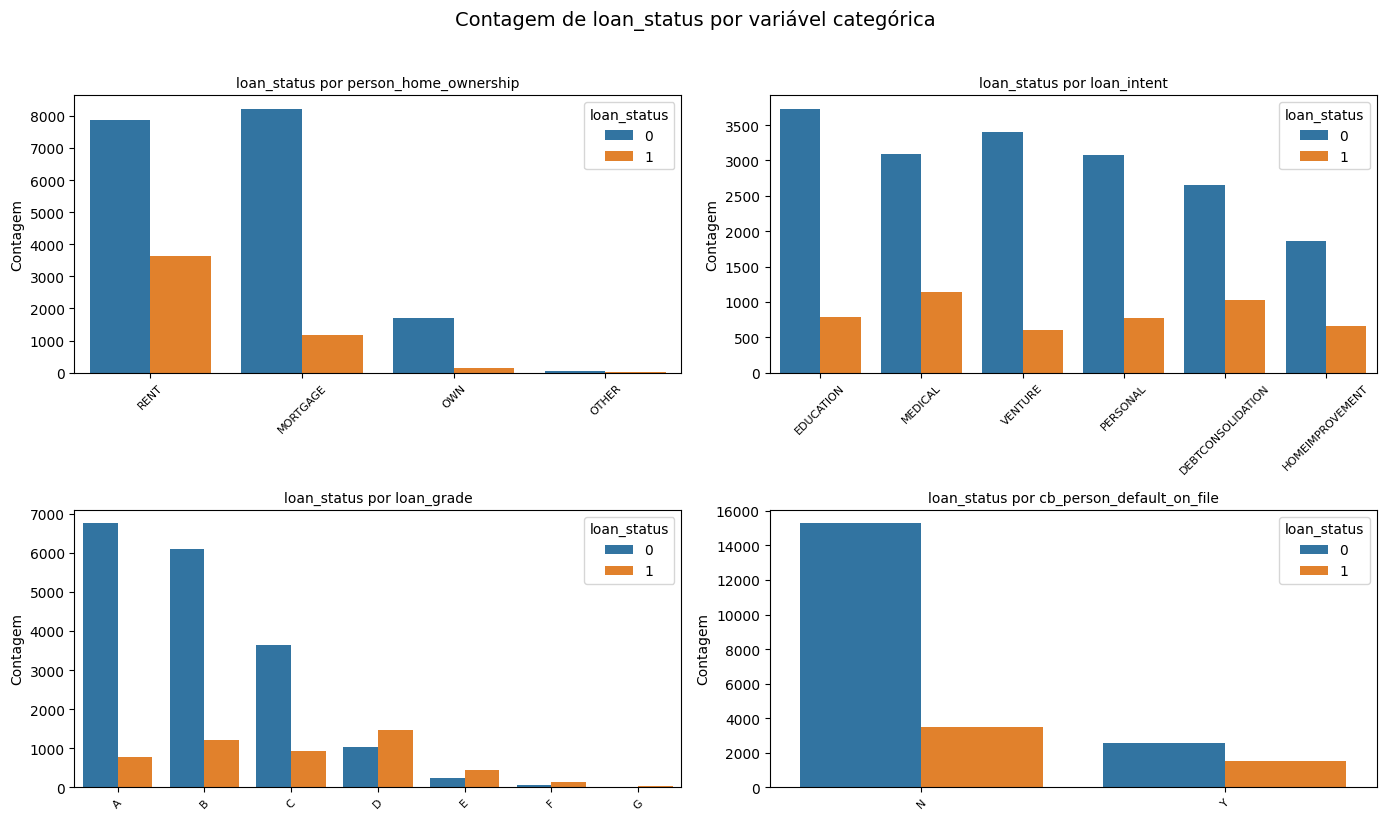

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Define a ordem das categorias pela contagem total de elementos
    ordem = df[col].value_counts().index.tolist()
    
    # O 'hue' separa o loan_status em barras de cores diferentes, lado a lado
    sns.countplot(
        data=df, x=col, hue='loan_status',
        order=ordem, ax=axes[i]
    )
    
    axes[i].set_title(f'loan_status por {col}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Contagem')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)

for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Contagem de loan_status por variável categórica', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Cramers'V Association test

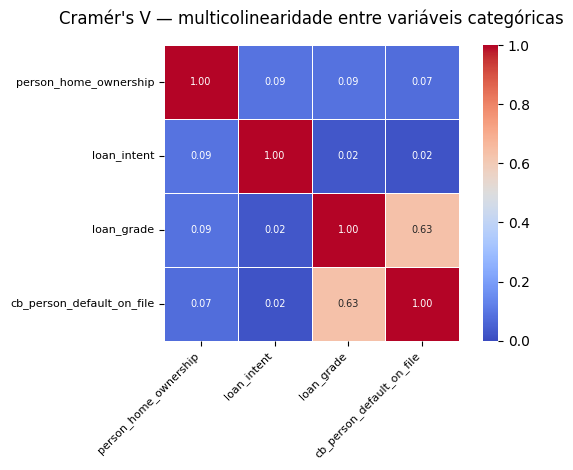


Pares com Cramér's V > 0.5 (possível multicolinearidade):

variavel_1                variavel_2  cramers_v
loan_grade cb_person_default_on_file     0.6344


In [18]:
cat_cols_vif = categorical_cols.columns.tolist()

def cramers_v(x, y):
    tabela = pd.crosstab(x, y)
    r, k = tabela.shape
    # evita divisão por zero quando uma variável tem só 1 categoria
    if min(r, k) <= 1:
        return 0.0
    chi2, _, _, _ = chi2_contingency(tabela)
    n = len(x)
    v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    return round(v, 4)

matriz = pd.DataFrame(index=cat_cols_vif, columns=cat_cols_vif, dtype=float)

for col1 in cat_cols_vif:
    for col2 in cat_cols_vif:
        if col1 == col2:
            matriz.loc[col1, col2] = 1.0
        else:
            dados = df[[col1, col2]].dropna()
            matriz.loc[col1, col2] = cramers_v(dados[col1], dados[col2])

# heatmap
plt.figure()
sns.heatmap(
    matriz.astype(float),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0.5,
    vmin=0, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title("Cramér's V — multicolinearidade entre variáveis categóricas", pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# pares com associação alta (V > 0.5)
print("\nPares com Cramér's V > 0.5 (possível multicolinearidade):\n")
pares = []
for i, col1 in enumerate(cat_cols_vif):
    for j, col2 in enumerate(cat_cols_vif):
        if j <= i:
            continue
        v = matriz.loc[col1, col2]
        if v > 0.5:
            pares.append({'variavel_1': col1, 'variavel_2': col2, 'cramers_v': v})

pares_df = pd.DataFrame(pares).sort_values('cramers_v', ascending=False)
print(pares_df.to_string(index=False))

A análise do mapa de calor de V de Cramer revelou uma associação estatisticamente relevante entre `loan_grade` (o grau/risco do empréstimo) e `cb_person_default_on_file` (histórico de inadimplência prévia).

O alto coeficiente de associação indica que estas variáveis compartilham informações redundantes. Em termos de negócio, isso faz sentido: o `loan_grade` geralmente é calculado pelas instituições financeiras justamente utilizando o histórico de inadimplência (`default_on_file`) como um de seus componentes principais.

Manter ambas as variáveis no modelo introduz multicolinearidade desnecessária. O algoritmo de classificação pode ter dificuldade em separar o peso de cada uma, pois, para o modelo, elas estão "contando a mesma história".

 O `loan_grade` costuma ser uma variável mais rica, pois, além do histórico de *default*, pode incorporar outros critérios (como renda e nível de endividamento).